# Random Forest Regression and Classification Models

The Random Forest Regressor models aim to calculate the strength of correlation between variables while the Classification models tries to predict the economic index based on chosen features.

In [1]:
# import necessary libraries
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_percentage_error,
    r2_score,
    accuracy_score,
    confusion_matrix,
    classification_report,
)
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# Function for model description

In [2]:
# For regression
def describe_model(y_test, y_pred):
    mae = np.mean(np.abs(y_test - y_pred))
    mse = np.mean((y_test - y_pred) ** 2)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # # Calculate the adjusted R^2 value
    # n = len(y_test)  # the number of observations
    # p = X_test.shape[1]  # the number of features

    # Adjusted R^2 formula
    # adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    # print("Adjusted R^2 Score:", adjusted_r2)

    results = {
        "Mean absolute error": [mae],
        "Mean absolute error [%]": [mape],
        "Mean squared error": [mse],
        "Root mean squared error": [rmse],
        "R2 score": [r2],
    }

    results = pd.DataFrame(results)

    return results


# For classification
def describe_model_class(y_test, y_pred):
    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.4f}\n")

    # Confusion Matrix
    matrix = confusion_matrix(y_test, y_pred)

    # Plot Confusion Matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

In [3]:
# Set seed to replicate results
np.random.seed(42)

# Read the JSON file
df = pd.read_json("all_data.json")

df.head()

,Country Name,year,Foreign Investment,GDP per Capita,Unemployment Rate,Labor Force participation rate,v4_prefixes_ris,v6_prefixes_ris,asns_ris,v4_prefixes_stats,v6_prefixes_stats,asns_stats,speed (mgps),bandwidth (kbit/s),Income group,imputed speed,imputed bandwidth,non_imputed_internet_index,imputed_internet_index,Economic Index_y
0,qatar,2022,0.296388,0.345357,0.000806,1.000000,0.008931,0.055823,0.002571,0.382979,0.382979,0.002623,0.352037,0.030656,High income,0.352037,0.030656,0.152325,0.152325,0.520737
1,qatar,2023,0.295860,0.312189,0.000806,0.999550,0.009345,0.068468,0.002371,0.574468,0.574468,0.002769,0.630353,NaN,High income,0.630353,0.068537,NaN,0.241347,0.554932
2,luxembourg,2021,0.346346,0.520874,0.146991,0.529915,0.025711,0.031610,0.015618,0.319149,0.319149,0.017734,0.710388,NaN,High income,0.710388,0.088587,NaN,0.190993,0.470416
3,qatar,2018,0.294219,0.276485,0.000269,0.998703,0.007602,0.002526,0.001653,0.255319,0.255319,0.002178,0.127383,0.012695,High income,0.127383,0.012695,0.083084,0.083084,0.488905
4,qatar,2021,0.295267,0.279262,0.001075,0.978165,0.008310,0.041304,0.002370,0.404255,0.404255,0.002479,0.446277,0.029791,High income,0.446277,0.029791,0.167380,0.167380,0.499364


### Feature preparation 

In [4]:
# Check for missing values
missing_values = df.isnull().sum()

print(missing_values)

# Handle some missing values
df["imputed speed"] = df["imputed speed"].fillna(df["imputed speed"].mean())
df["Economic Index_y"] = df["Economic Index_y"].fillna(df["Economic Index_y"].mean())

Country Name                        0
year                                0
Foreign Investment                 63
GDP per Capita                     18
Unemployment Rate                  46
Labor Force participation rate     55
v4_prefixes_ris                     0
v6_prefixes_ris                     0
asns_ris                            0
v4_prefixes_stats                   0
v6_prefixes_stats                   0
asns_stats                          0
speed (mgps)                      181
bandwidth (kbit/s)                262
Income group                       45
imputed speed                       4
imputed bandwidth                   0
non_imputed_internet_index        401
imputed_internet_index              4
Economic Index_y                   81
dtype: int64


### Train and test sets 

In [5]:
# Define X and Y
X = df[
    [
        "v4_prefixes_ris",
        "v6_prefixes_ris",
        "asns_ris",
        "v4_prefixes_stats",
        "v6_prefixes_stats",
        "asns_stats",
        "imputed speed",
        "imputed bandwidth",
    ]
]
Y = df["Economic Index_y"]

# Add logarithmic transformation as some variables are skewed to the right, add 1 to avoid log(0)
X["transformed_bandwidth"] = np.log(X["imputed bandwidth"] + 1)
X["transformed_v4_prefixes_ris"] = np.log(X["v4_prefixes_ris"] + 1)
X["transformed_speed"] = np.log(X["imputed speed"] + 1)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, train_size=0.8, random_state=42
)

# Check the distribution of the target variable
print(f"Distribution of target variable: /n {y_train.describe()}")

Distribution of target variable: /n count    504.000000
mean       0.192106
std        0.127348
min       -0.062476
25%        0.101530
50%        0.192091
75%        0.261582
max        0.557732
Name: Economic Index_y, dtype: float64


C:\Users\maria\AppData\Local\Temp\ipykernel_11872\2432426114.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["transformed_bandwidth"] = np.log(X["imputed bandwidth"] + 1)
C:\Users\maria\AppData\Local\Temp\ipykernel_11872\2432426114.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["transformed_v4_prefixes_ris"] = np.log(X["v4_prefixes_ris"] + 1)
C:\Users\maria\AppData\Local\Temp\ipykernel_11872\2432426114.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Dat

# First random forest regressor

In [6]:
# Avoid logaritmic features for this model
X_train_1 = X_train.drop(
    columns=[
        "transformed_bandwidth",
        "transformed_v4_prefixes_ris",
        "transformed_speed",
    ]
)
X_test_1 = X_test.drop(
    columns=[
        "transformed_bandwidth",
        "transformed_v4_prefixes_ris",
        "transformed_speed",
    ]
)

# Run the random forest regression model
rf_original = RandomForestRegressor(n_estimators=100, random_state=42)

# Fit the model to the training data
rf_original.fit(X_train_1, y_train)

# Make predictions on the test data
y_pred = rf_original.predict(X_test_1)

# Get results
results = describe_model(y_test, y_pred)
results

,Mean absolute error,Mean absolute error [%],Mean squared error,Root mean squared error,R2 score
0,0.053796,1.341715,0.005987,0.077374,0.609498


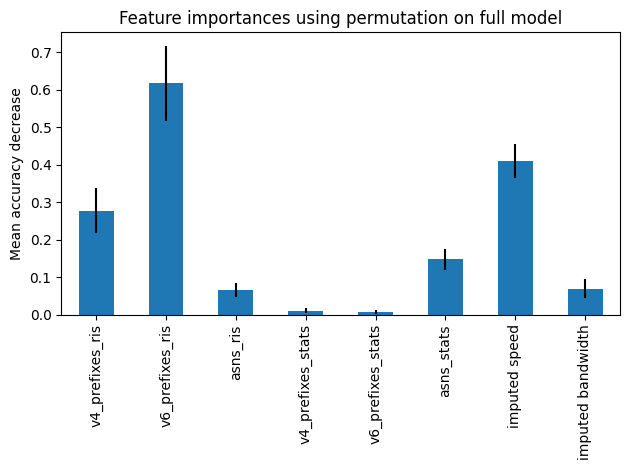

In [7]:
# Calculate the feature importance for the Random Forest model using permutation importance
p_importance = permutation_importance(
    rf_original, X_test_1, y_test, n_repeats=10, n_jobs=2
)
forest_importances = pd.Series(p_importance.importances_mean, index=X_test_1.columns)

# Visualise feature importance
fig, ax = plt.subplots()
forest_importances.plot.bar(yerr=p_importance.importances_std, ax=ax)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
fig.tight_layout()
plt.show()

#### Insights

The variables represeting IPV4 and IPV6 stats may appear insignificant as they have low impact on accuracy. However, the result of low accouracy is due to high correlation (correlation is 1) between the two variables. Therefore, it is important to still include 1 of the variables to the model.

## Random Forest Regressor Model with Logarithmic Transformations 

In [8]:
# Include logaritmic features for this model
X_train_2 = X_train.drop(
    columns=["imputed bandwidth", "v4_prefixes_ris", "imputed speed"]
)
X_test_2 = X_test.drop(
    columns=["imputed bandwidth", "v4_prefixes_ris", "imputed speed"]
)

# run a random forest regression model
rf_transformed = RandomForestRegressor(n_estimators=100, random_state=42)

# Fit the model to the training data
rf_transformed.fit(X_train_2, y_train)

# Make predictions on the test data
y_pred = rf_transformed.predict(X_test_2)

# Get results
results = describe_model(y_test, y_pred)
results

,Mean absolute error,Mean absolute error [%],Mean squared error,Root mean squared error,R2 score
0,0.052947,1.321377,0.005801,0.076163,0.621624


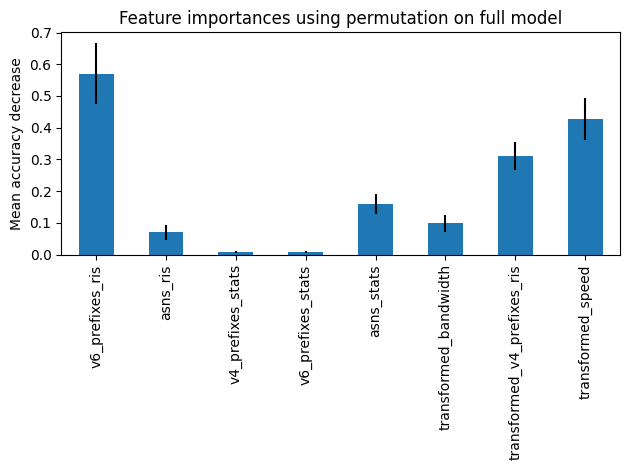

In [9]:
# Feature importance
p_importance = permutation_importance(
    rf_transformed, X_test_2, y_test, n_repeats=10, n_jobs=2
)
forest_importances = pd.Series(p_importance.importances_mean, index=X_test_2.columns)

# Visualisation
fig, ax = plt.subplots()
forest_importances.plot.bar(yerr=p_importance.importances_std, ax=ax)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
fig.tight_layout()
plt.show()

#### Insights

The model with logarithmic transformation has a slightly higher R2 score, however, the importance of ipv4 in ris dropped slightly. Concluding, transforming variables doesn't change the results significantly probably due to the reason that Random Forest Model isn't affected by tranformations in a significant manner by default.

# Random forest excluding v6_prefixes stats and logarithmic tranformations

In [10]:
# Avoid logaritmic features for this model
X_train_3 = X_train.drop(
    columns=[
        "transformed_bandwidth",
        "transformed_v4_prefixes_ris",
        "transformed_speed",
        "v6_prefixes_stats",
    ]
)
X_test_3 = X_test.drop(
    columns=[
        "transformed_bandwidth",
        "transformed_v4_prefixes_ris",
        "transformed_speed",
        "v6_prefixes_stats",
    ]
)

# run the random forest regression model
rf_3 = RandomForestRegressor(n_estimators=100, random_state=42)

# Fit the model to the training data
rf_3.fit(X_train_3, y_train)

# Make predictions on the test data
y_pred = rf_3.predict(X_test_3)

# Get results
results = describe_model(y_test, y_pred)
results

,Mean absolute error,Mean absolute error [%],Mean squared error,Root mean squared error,R2 score
0,0.053506,1.31677,0.005958,0.077191,0.611346


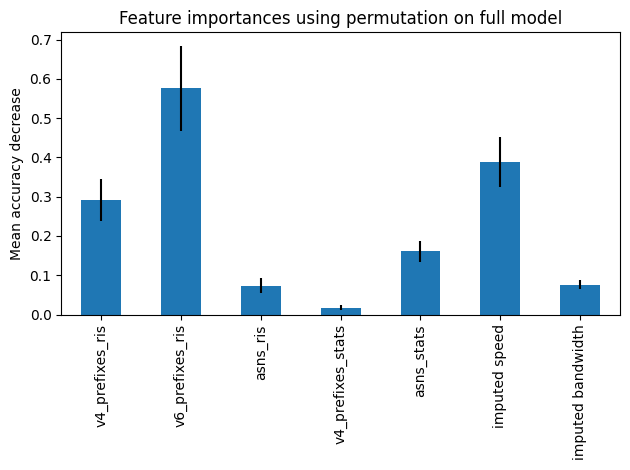

In [11]:
# Feature importance
p_importance = permutation_importance(rf_3, X_test_3, y_test, n_repeats=10, n_jobs=2)
forest_importances = pd.Series(p_importance.importances_mean, index=X_test_3.columns)

# Visualisation
fig, ax = plt.subplots()
forest_importances.plot.bar(yerr=p_importance.importances_std, ax=ax)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
fig.tight_layout()
plt.show()

#### Insights

The use of v4 stats variable still seems insignificant after removing the highly correlated v6 stats. Another model will be run excluding v4 stats as well to assess its performance.

# Random forest regressor excluding v6 stats and v4 stats

In [12]:
# Avoid logaritmic features for this model
X_train_4 = X_train.drop(
    columns=[
        "transformed_bandwidth",
        "transformed_v4_prefixes_ris",
        "transformed_speed",
        "v6_prefixes_stats",
        "v4_prefixes_stats",
    ]
)
X_test_4 = X_test.drop(
    columns=[
        "transformed_bandwidth",
        "transformed_v4_prefixes_ris",
        "transformed_speed",
        "v6_prefixes_stats",
        "v4_prefixes_stats",
    ]
)

# run the random forest regression model
rf_4 = RandomForestRegressor(n_estimators=100, random_state=42)

# Fit the model to the training data
rf_4.fit(X_train_4, y_train)

# Make predictions on the test data
y_pred = rf_4.predict(X_test_4)

# Get results
results = describe_model(y_test, y_pred)
results

,Mean absolute error,Mean absolute error [%],Mean squared error,Root mean squared error,R2 score
0,0.051797,1.303726,0.005693,0.075454,0.628636


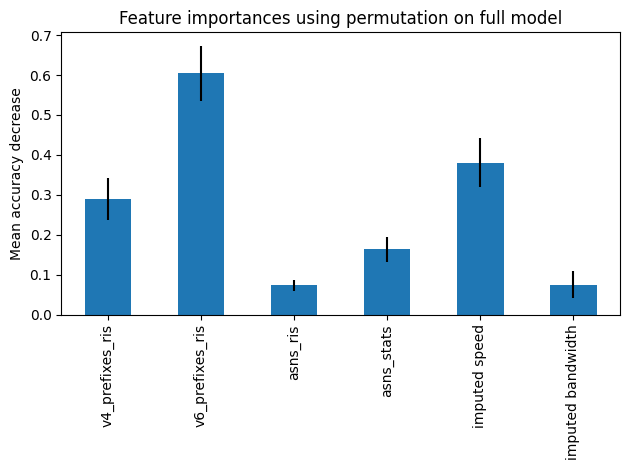

In [13]:
# Feature importance
p_importance = permutation_importance(rf_4, X_test_4, y_test, n_repeats=10, n_jobs=2)
forest_importances = pd.Series(p_importance.importances_mean, index=X_test_4.columns)

# Visualisation
fig, ax = plt.subplots()
forest_importances.plot.bar(yerr=p_importance.importances_std, ax=ax)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
fig.tight_layout()
plt.show()

#### Insights

This is the best performing model. To increase accuracy, we will experiment with number of estimators.

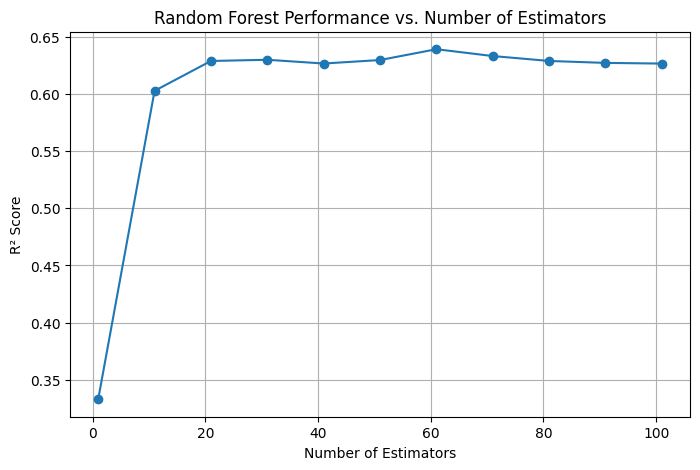

In [14]:
est_results = {}

for estimator in range(1, 110, 10):
    # fit model
    rf_5 = RandomForestRegressor(n_estimators=estimator, random_state=42)
    rf_5.fit(X_train_4, y_train)

    # Make predictions on the test data
    y_pred = rf_5.predict(X_test_4)

    # Get results
    results = describe_model(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    if estimator not in est_results:
        est_results[estimator] = r2

# Plot results
plt.figure(figsize=(8, 5))
plt.plot(list(est_results.keys()), list(est_results.values()), marker="o")
plt.xlabel("Number of Estimators")
plt.ylabel("R² Score")
plt.title("Random Forest Performance vs. Number of Estimators")
plt.grid(True)
plt.show()

#### Insights

The best perfroming model includes 31 estimators and features that exclude ipv4 and ipv6 stats.

# Random forest regressor final model

In [15]:
# fit model
rf_final = RandomForestRegressor(n_estimators=31, random_state=42)
rf_final.fit(X_train_4, y_train)

# Make predictions on the test data
y_pred_final = rf_final.predict(X_test_4)

# Get results
results = describe_model(y_test, y_pred_final)
results

,Mean absolute error,Mean absolute error [%],Mean squared error,Root mean squared error,R2 score
0,0.051984,1.40277,0.005677,0.075344,0.62972


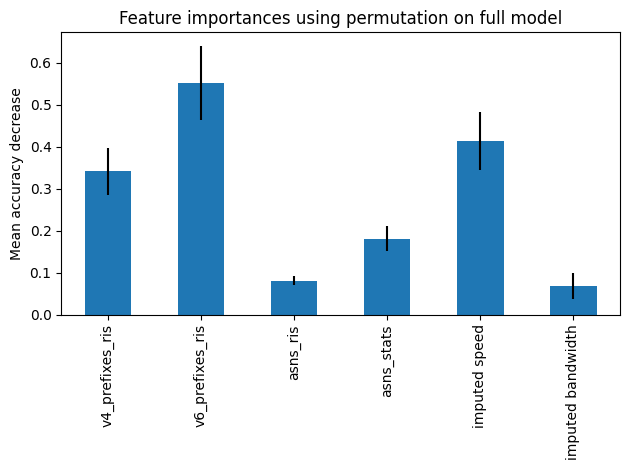

In [16]:
# Feature importance
p_importance = permutation_importance(
    rf_final, X_test_4, y_test, n_repeats=10, n_jobs=2
)
forest_importances = pd.Series(p_importance.importances_mean, index=X_test_4.columns)

# Visualisation
fig, ax = plt.subplots()
forest_importances.plot.bar(yerr=p_importance.importances_std, ax=ax)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
fig.tight_layout()
plt.show()

# Random forest classifiers

In [17]:
# Drop rows with missing income group
rf_df = df.dropna(subset="Income group")

# Define variables
Y = rf_df["Income group"]
X = rf_df[
    [
        "v4_prefixes_ris",
        "v6_prefixes_ris",
        "asns_ris",
        "v4_prefixes_stats",
        "v6_prefixes_stats",
        "asns_stats",
        "imputed speed",
        "imputed bandwidth",
    ]
]

# Split to train test
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, train_size=0.8, random_state=42
)

## Random forest classifier without log features

Accuracy: 0.9231



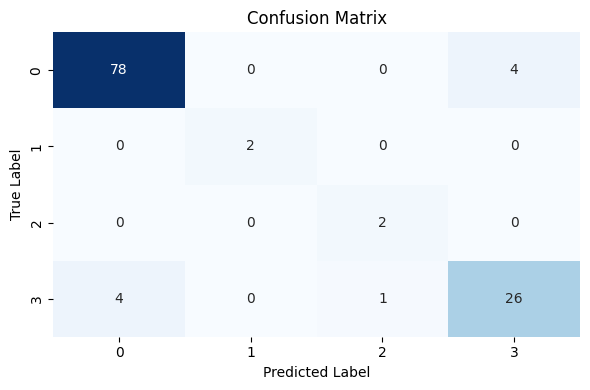


Classification Report:
                     precision    recall  f1-score   support

        High income       0.95      0.95      0.95        82
         Low income       1.00      1.00      1.00         2
Lower middle income       0.67      1.00      0.80         2
Upper middle income       0.87      0.84      0.85        31

           accuracy                           0.92       117
          macro avg       0.87      0.95      0.90       117
       weighted avg       0.92      0.92      0.92       117



In [18]:
# run the random forest regression model
rf_class = RandomForestClassifier(n_estimators=100, random_state=42)

# Fit the model to the training data
rf_class.fit(X_train, y_train)

# Make predictions on the test data
y_pred = rf_class.predict(X_test)

# Get results
results = describe_model_class(y_test, y_pred)
results

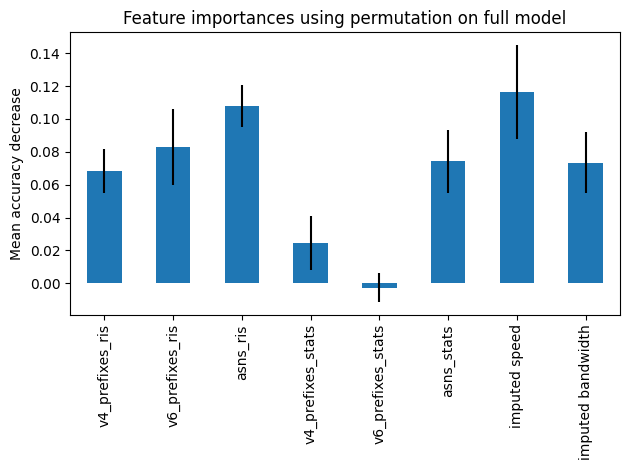

In [19]:
# Feature importance
p_importance = permutation_importance(rf_class, X_test, y_test, n_repeats=10, n_jobs=2)
forest_importances = pd.Series(p_importance.importances_mean, index=X_test.columns)

# Visualisation
fig, ax = plt.subplots()
forest_importances.plot.bar(yerr=p_importance.importances_std, ax=ax)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
fig.tight_layout()
plt.show()

## Random forest classifier without v4 stats

Accuracy: 0.9316



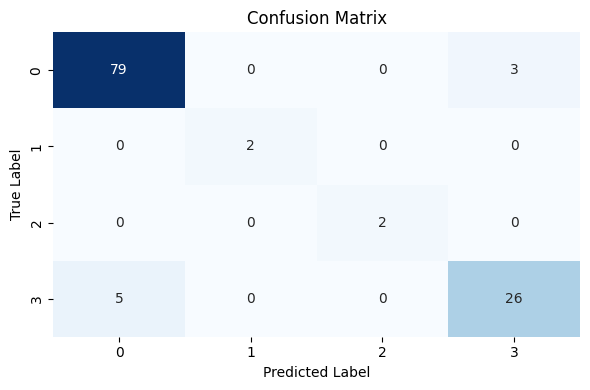


Classification Report:
                     precision    recall  f1-score   support

        High income       0.94      0.96      0.95        82
         Low income       1.00      1.00      1.00         2
Lower middle income       1.00      1.00      1.00         2
Upper middle income       0.90      0.84      0.87        31

           accuracy                           0.93       117
          macro avg       0.96      0.95      0.95       117
       weighted avg       0.93      0.93      0.93       117



In [20]:
X_train_1 = X_train.drop(columns=["v4_prefixes_stats"])
X_test_1 = X_test.drop(columns=["v4_prefixes_stats"])

# run the random forest regression model
rf_class_1 = RandomForestClassifier(n_estimators=100, random_state=42)

# Fit the model to the training data
rf_class_1.fit(X_train_1, y_train)

# Make predictions on the test data
y_pred = rf_class_1.predict(X_test_1)

# Get results
results = describe_model_class(y_test, y_pred)
results

#### Insights

This model is slightly better then previous one in terms of accuraccy.

## Random forest classfier without v6 and v4 stats

Accuracy: 0.9231



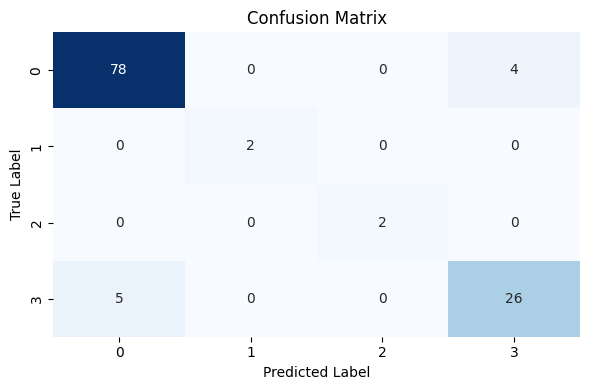


Classification Report:
                     precision    recall  f1-score   support

        High income       0.94      0.95      0.95        82
         Low income       1.00      1.00      1.00         2
Lower middle income       1.00      1.00      1.00         2
Upper middle income       0.87      0.84      0.85        31

           accuracy                           0.92       117
          macro avg       0.95      0.95      0.95       117
       weighted avg       0.92      0.92      0.92       117



In [21]:
X_train_2 = X_train.drop(columns=["v4_prefixes_stats", "v6_prefixes_stats"])
X_test_2 = X_test.drop(columns=["v4_prefixes_stats", "v6_prefixes_stats"])

# run the random forest regression model
rf_class_2 = RandomForestClassifier(n_estimators=100, random_state=42)

# Fit the model to the training data
rf_class_2.fit(X_train_2, y_train)

# Make predictions on the test data
y_pred = rf_class_2.predict(X_test_2)

# Get results
results = describe_model_class(y_test, y_pred)
results

#### Insights

This model performs worse in comparison to the previous one.

## Random forest classifier without v6 stats

Accuracy: 0.9316



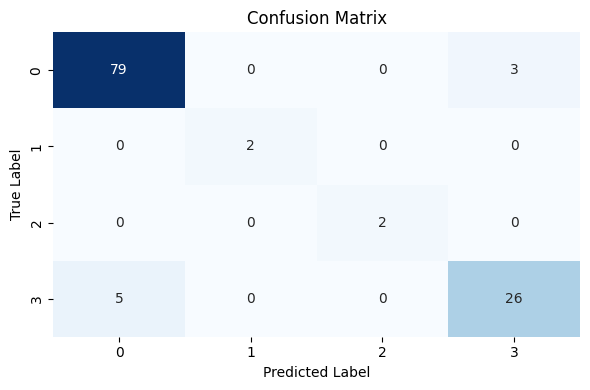


Classification Report:
                     precision    recall  f1-score   support

        High income       0.94      0.96      0.95        82
         Low income       1.00      1.00      1.00         2
Lower middle income       1.00      1.00      1.00         2
Upper middle income       0.90      0.84      0.87        31

           accuracy                           0.93       117
          macro avg       0.96      0.95      0.95       117
       weighted avg       0.93      0.93      0.93       117



In [22]:
X_train_3 = X_train.drop(columns=["v6_prefixes_stats"])
X_test_3 = X_test.drop(columns=["v6_prefixes_stats"])

# run the random forest regression model
rf_class_3 = RandomForestClassifier(n_estimators=100, random_state=42)

# Fit the model to the training data
rf_class_3.fit(X_train_3, y_train)

# Make predictions on the test data
y_pred = rf_class_3.predict(X_test_3)

# Get results
results = describe_model_class(y_test, y_pred)
results

### Insights

This model outperforms the previous one and has the same accuracy score as model that excludes Ipv4 stats. The identical accuracy scores of these model is explained by the perfect correlation between Ipv4 and Ipv6 features (correlation is 1).

We will experiment with number of estimators for this model to see whether accuracy can be better.

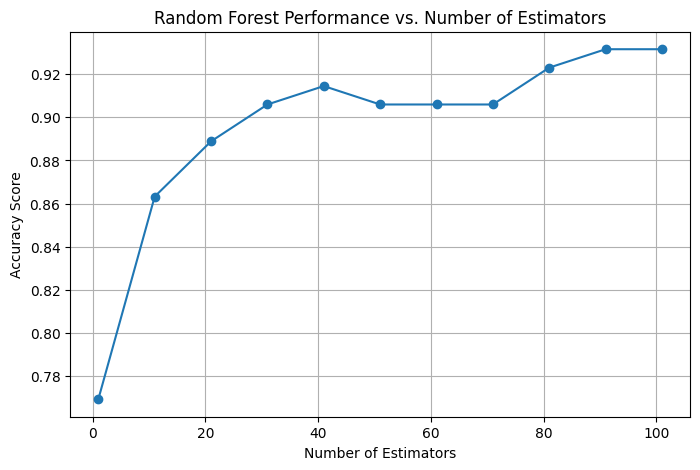

In [23]:
est_results = {}

for estimator in range(1, 110, 10):
    # fit model
    rf_class_4 = RandomForestClassifier(n_estimators=estimator, random_state=42)
    rf_class_4.fit(X_train_3, y_train)

    # Make predictions on the test data
    y_pred = rf_class_4.predict(X_test_3)

    # Get results
    accuracy = accuracy_score(y_test, y_pred)

    if estimator not in est_results:
        est_results[estimator] = accuracy

# Plot results
plt.figure(figsize=(8, 5))
plt.plot(list(est_results.keys()), list(est_results.values()), marker="o")
plt.xlabel("Number of Estimators")
plt.ylabel("Accuracy Score")
plt.title("Random Forest Performance vs. Number of Estimators")
plt.grid(True)
plt.show()

The number of estimators should stay 100 for the best accuracy, therefore, the model developed before is the best perfroming model.